# EXAMEN PRIMER BIMESTRE RI

#### **Nombre:** Kenneth Yar

## 1. Instalación de dependencias

In [36]:
!pip install sentence-transformers scikit-learn pandas numpy matplotlib nltk

## 2. Importación de librerías

In [19]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.stem import PorterStemmer

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer


## 3. Carga del corpus

In [20]:
path = "/kaggle/input/datasets/stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset"

movies = pd.read_csv(f"{path}/rotten_tomatoes_movies.csv")
reviews = pd.read_csv(f"{path}/rotten_tomatoes_critic_reviews.csv")

documentos = reviews["review_content"].dropna().tolist()

print("Documentos:", len(documentos))
print(documentos[0])

Documentos: 1064211
A fantasy adventure that fuses Greek mythology to contemporary American places and values. Anyone around 15 (give or take a couple of years) will thrill to the visual spectacle


## 4. Selección de campos textuales

In [35]:
# ── Selección de campos textuales ─────────────────────────────────────
print("Columnas disponibles en reviews:")
print(reviews.columns.tolist())

print("\nColumnas disponibles en movies:")
print(movies.columns.tolist())

# Campo seleccionado para representar cada documento
CAMPO_TEXTO = "review_content"

print(f"\nCampo seleccionado: '{CAMPO_TEXTO}'")
print("Justificación: contiene la opinión textual del crítico,")
print("que es el contenido semántico más rico para recuperación.")
print(f"\nEjemplo de documento:\n{reviews[CAMPO_TEXTO].dropna().iloc[0]}")

Columnas disponibles en reviews:
['rotten_tomatoes_link', 'critic_name', 'top_critic', 'publisher_name', 'review_type', 'review_score', 'review_date', 'review_content']

Columnas disponibles en movies:
['rotten_tomatoes_link', 'movie_title', 'movie_info', 'critics_consensus', 'content_rating', 'genres', 'directors', 'authors', 'actors', 'original_release_date', 'streaming_release_date', 'runtime', 'production_company', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_status', 'audience_rating', 'audience_count', 'tomatometer_top_critics_count', 'tomatometer_fresh_critics_count', 'tomatometer_rotten_critics_count']

Campo seleccionado: 'review_content'
Justificación: contiene la opinión textual del crítico,
que es el contenido semántico más rico para recuperación.

Ejemplo de documento:
A fantasy adventure that fuses Greek mythology to contemporary American places and values. Anyone around 15 (give or take a couple of years) will thrill to the visual spectacle


## 5. Preprocesamiento

In [21]:
stemmer = PorterStemmer()

def procesar(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-z\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()

    tokens = texto.split()
    tokens = [stemmer.stem(p) for p in tokens]

    return ' '.join(tokens)

corpus_final = [procesar(doc) for doc in documentos]

## 6. Embeddings

#### Muestreo del corpus

El corpus original contiene 1,064,211 reseñas. La generación  de embeddings con esta cantidad grande tiene un costo computacional alto por lo que se tomó una muestra aleatoria reproducible de 50,000 documentos (seed=42) para hacer la experimentación.

In [22]:
SAMPLE_SIZE = 50_000
np.random.seed(42)

reviews_clean = reviews.dropna(subset=["review_content"]).reset_index(drop=True)
indices = np.random.choice(len(reviews_clean), size=SAMPLE_SIZE, replace=False)
df_muestra = reviews_clean.iloc[indices].reset_index(drop=True)

corpus_muestra = [procesar(doc) for doc in df_muestra["review_content"].tolist()]
print(f"Corpus: {len(corpus_muestra)} documentos")

Corpus: 50000 documentos


### Modelo 1

In [23]:
modelo = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = modelo.encode(
    corpus_muestra,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/196 [00:00<?, ?it/s]

(50000, 384)


#### Unir títulos de películas

In [24]:
df_muestra = df_muestra.merge(
    movies[["rotten_tomatoes_link", "movie_title"]],
    on="rotten_tomatoes_link",
    how="left"
)

## 7. Recuperación

In [25]:
def buscar(consulta, k=5):
    q_emb = modelo.encode([procesar(consulta)], convert_to_numpy=True)
    sims = cosine_similarity(q_emb, embeddings)[0]
    top_k = np.argsort(sims)[::-1][:k]
    
    filas = []
    for rank, idx in enumerate(top_k, start=1):
        filas.append({
            "Ranking":   rank,
            "ID_doc":    idx,
            "Título":    df_muestra.iloc[idx]["movie_title"],
            "Fragmento": df_muestra.iloc[idx]["review_content"][:200],
            "Similitud": round(float(sims[idx]), 4)
        })
    return pd.DataFrame(filas)

## 8. Benchmark de consultas

In [26]:
QUERIES = {
    "Q1": "science fiction movie with advanced technology",
    "Q2": "romantic story with emotional relationships",
    "Q3": "action movie with intense fight scenes",
    "Q4": "horror film that creates fear and suspense",
    "Q5": "visually impressive movie with weak storyline",
    "Q6": "emotionally moving performance by the lead actor",
    "Q7": "predictable plot but entertaining experience",
    "Q8": "movie praised by critics but unpopular with audiences",
}

resultados = {}
for qid, texto in QUERIES.items():
    print(f"\n{'='*50}\n{qid}: {texto}")
    resultados[qid] = buscar(texto, k=5)
    display(resultados[qid])


Q1: science fiction movie with advanced technology


,Ranking,ID_doc,Título,Fragmento,Similitud
0,1,49607,Kaena: The Prophecy,A technically impressive if narratively muddle...,0.6169
1,2,40685,Looper,"This is a ""you know what would be cool?"" movie...",0.6095
2,3,20461,Escape from the Planet of the Apes,"One of the better new movies in town, and bett...",0.6077
3,4,38754,Cloud Atlas,One of the best science fiction movies I have ...,0.6030
4,5,2761,Akira,Still one of the best techno science fiction t...,0.5927



Q2: romantic story with emotional relationships


,Ranking,ID_doc,Título,Fragmento,Similitud
0,1,7097,The Aftermath,It would be one thing if the romance meant som...,0.5949
1,2,770,How to Train Your Dragon 2,It might ramp up the action and the emotional ...,0.5801
2,3,25753,High Fidelity,One of the sharpest and emotionally resonant r...,0.5552
3,4,29243,Anya,This love story packs an emotional punch with ...,0.5463
4,5,40046,Eternal Sunshine of the Spotless Mind,A surprisingly bittersweet love story at heart...,0.5395



Q3: action movie with intense fight scenes


...

,Ranking,ID_doc,Título,Fragmento,Similitud
0,1,28902,Bombshell: The Hedy Lamarr Story,This film is packed with emotional kicks.,0.6002
1,2,45208,Magnolia,The most emotionally powerful film I have seen...,0.5484
2,3,32057,We Are Your Friends,Zac Efron and Emily Ratajkowski are both extre...,0.5481
3,4,15758,The Town,The emotional action in The Town is just as gr...,0.5445
4,5,6276,The Descendants,In playing an everyman stranded between anger ...,0.5314



Q7: predictable plot but entertaining experience


,Ranking,ID_doc,Título,Fragmento,Similitud
0,1,12439,The Recruit,Rather predictable but slick entertainment.,0.6515
1,2,10690,The Recruit,Rather predictable but slick entertainment.,0.6515
2,3,10590,Step Up Revolution,Fabulous dancing but a dumb plot. Even predict...,0.5938
3,4,43809,Unstoppable,It's predictable but plausible and exciting...,0.5639
4,5,16773,The Brothers Grimm,"Until the plot goes wrong, this is a thoroughl...",0.5628



Q8: movie praised by critics but unpopular with audiences


,Ranking,ID_doc,Título,Fragmento,Similitud
0,1,35325,The Lobster,An rare movie that some will enjoy with passio...,0.6126
1,2,45787,Bad Times at the El Royale,"This tedious, arrogant film is precisely the t...",0.6054
2,3,8149,Gone With the Wind,A critic-proof movie if there ever was one: it...,0.6029
3,4,36452,The Prey,It is not so much about this movie being bad a...,0.5946
4,5,34543,Scream 3,The closure that goes all the way. It's failed...,0.5933


#### Tabla resumen

In [27]:
resumen = []
for qid, df_res in resultados.items():
    top1 = df_res.iloc[0]
    resumen.append({
        "Consulta":  f"{qid}: {QUERIES[qid]}",
        "Doc Top-1": top1["ID_doc"],
        "Título":    top1["Título"],
        "Similitud": top1["Similitud"]
    })

display(pd.DataFrame(resumen))

,Consulta,Doc Top-1,Título,Similitud
0,Q1: science fiction movie with advanced techno...,49607,Kaena: The Prophecy,0.6169
1,Q2: romantic story with emotional relationships,7097,The Aftermath,0.5949
2,Q3: action movie with intense fight scenes,28491,The Raid 2,0.6847
3,Q4: horror film that creates fear and suspense,42136,The Fly,0.6886
4,Q5: visually impressive movie with weak storyline,18917,The Lion King,0.6407
5,Q6: emotionally moving performance by the lead...,28902,Bombshell: The Hedy Lamarr Story,0.6002
6,Q7: predictable plot but entertaining experience,12439,The Recruit,0.6515
7,Q8: movie praised by critics but unpopular wit...,35325,The Lobster,0.6126


## 9. Desafío de excelencia

### Modelo 2 (más pesado, mayor capacidad semántica) 

In [28]:
modelo2 = SentenceTransformer("all-mpnet-base-v2")

embeddings2 = modelo2.encode(
    corpus_muestra,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(embeddings2.shape)  # (50000, 768)  ← dimensión mayor que MiniLM

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/391 [00:00<?, ?it/s]

(50000, 768)


#### Análisis comparativo

MPNet genera similitudes más altas en promedio debido a su mayor 
dimensionalidad (768 vs 384).

#### Función genérica que acepta cualquier modelo/embeddings

In [29]:
def buscar_con(consulta, embs, mdl, k=5):
    q_emb = mdl.encode([procesar(consulta)], convert_to_numpy=True)
    sims  = cosine_similarity(q_emb, embs)[0]
    top_k = np.argsort(sims)[::-1][:k]
    filas = []
    for rank, idx in enumerate(top_k, start=1):
        filas.append({
            "Ranking":   rank,
            "Título":    df_muestra.iloc[idx]["movie_title"],
            "Fragmento": df_muestra.iloc[idx]["review_content"][:150],
            "Similitud": round(float(sims[idx]), 4)
        })
    return pd.DataFrame(filas)

#### Tabla comparativa para las 8 queries

In [31]:
print("COMPARACIÓN DE MODELOS — Top-1 por consulta\n")

filas_comp = []
for qid, texto in QUERIES.items():
    r1 = buscar_con(texto, embeddings, modelo)   # MiniLM
    r2 = buscar_con(texto, embeddings2, modelo2)  # MPNet
    filas_comp.append({
        "Consulta":         f"{qid}",
        "MiniLM Top-1":     r1.iloc[0]["Título"],
        "MiniLM Sim":       r1.iloc[0]["Similitud"],
        "MPNet Top-1":      r2.iloc[0]["Título"],
        "MPNet Sim":        r2.iloc[0]["Similitud"],
    })

df_comp = pd.DataFrame(filas_comp)
display(df_comp)

COMPARACIÓN DE MODELOS — Top-1 por consulta

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,Consulta,MiniLM Top-1,MiniLM Sim,MPNet Top-1,MPNet Sim
0,Q1,Kaena: The Prophecy,0.6169,Kaena: The Prophecy,0.7175
1,Q2,The Aftermath,0.5949,Light of My life,0.6143
2,Q3,The Raid 2,0.6847,The Raid 2,0.6948
3,Q4,The Fly,0.6886,Super 8,0.7366
4,Q5,The Lion King,0.6407,The Fall,0.5900
5,Q6,Bombshell: The Hedy Lamarr Story,0.6002,Precious: Based on the Novel Push by Sapphire,0.6104
6,Q7,The Recruit,0.6515,The Recruit,0.6797
7,Q8,The Lobster,0.6126,Scream 3,0.5453


## Visualización PCA

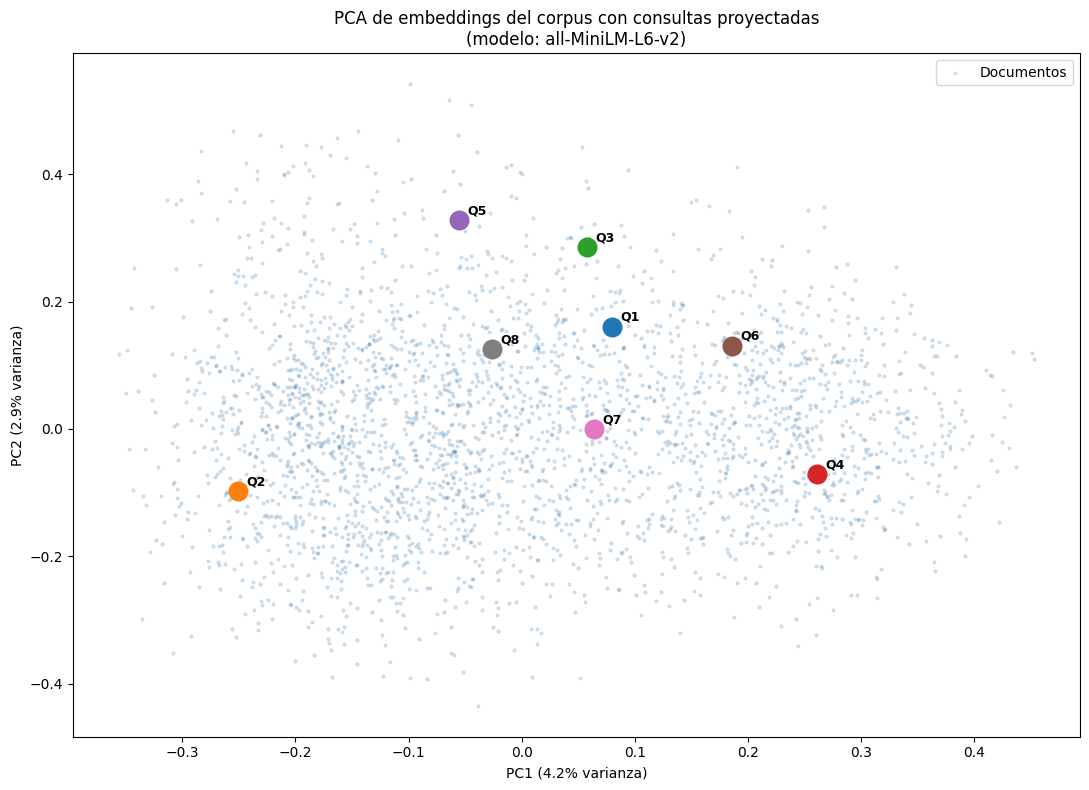

In [34]:
# PCA sobre embeddings del corpus + queries proyectadas
N_VIZ = 3000  # puntos del corpus a graficar
idx_viz = np.random.choice(len(embeddings), N_VIZ, replace=False)

pca = PCA(n_components=2, random_state=42)
pca.fit(embeddings[idx_viz])  # ajustar solo con MiniLM

coords_corpus = pca.transform(embeddings[idx_viz])

# Proyectar las 8 queries
queries_emb = modelo.encode(
    [procesar(t) for t in QUERIES.values()],
    convert_to_numpy=True
)
coords_queries = pca.transform(queries_emb)

#  Gráfica
fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(
    coords_corpus[:, 0], coords_corpus[:, 1],
    s=4, alpha=0.2, color="steelblue", label="Documentos"
)

colores = plt.cm.tab10.colors
for i, (qid, texto) in enumerate(QUERIES.items()):
    x, y = coords_queries[i]
    ax.scatter(x, y, s=180, zorder=5, color=colores[i])
    ax.annotate(
        f"{qid}", (x, y),
        fontsize=9, fontweight="bold",
        xytext=(6, 4), textcoords="offset points"
    )

varianza = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({varianza[1]*100:.1f}% varianza)")
ax.set_title("PCA de embeddings del corpus con consultas proyectadas\n(modelo: all-MiniLM-L6-v2)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("pca_embeddings.png", dpi=150)
plt.show()